# 05. 추가 실험 (안정성 · 조기 예측)
3. Valid 분할 안정성 : Hold-out 셀을 다르게 뽑아도 같은 모델이 선택되는가?
4. 조기 예측 민감도 : 100 사이클보다 적은 사이클만으로도 예측이 되는가?

공식 성능 표와 별개의 참고 실험이다.

[실험 3] Valid 분할 안정성 (30회 반복, 2~3분 소요)
  분할 30/30
                 모델  Valid 1위 횟수  Valid MAPE 평균(%)  Valid MAPE 표준편차 Valid MAPE 최소~최대  Test MAPE 평균(%)  Test MAPE 표준편차
  Linear (variance)            9              9.19             2.44       5.1 ~ 15.3            28.88            0.92
  ElasticNet (main)           12             10.50             5.56       5.1 ~ 26.7            36.12            7.29
  ElasticNet (full)            5              9.91             3.85       5.3 ~ 19.6            39.52            6.65
RandomForest (main)            3             11.26             3.02       6.2 ~ 19.1            36.10            4.73
    LightGBM (main)            1             12.85             3.20       8.1 ~ 18.9            38.90            6.28
{'반복 횟수': 30, 'Valid 셀 수 범위': '6 ~ 8', '선택된 모델의 Test MAPE 평균(%)': 35.44}

[실험 4] 조기 예측 민감도 (Linear, 피처 = log Var(Q_n − Q_10))
 사용 사이클 n  Batch 1 상관 r  Valid MAPE(%)  Test MAPE(%)  Batch 2 단수명(<550) 판별 AUC
       20        -0.375          16.86

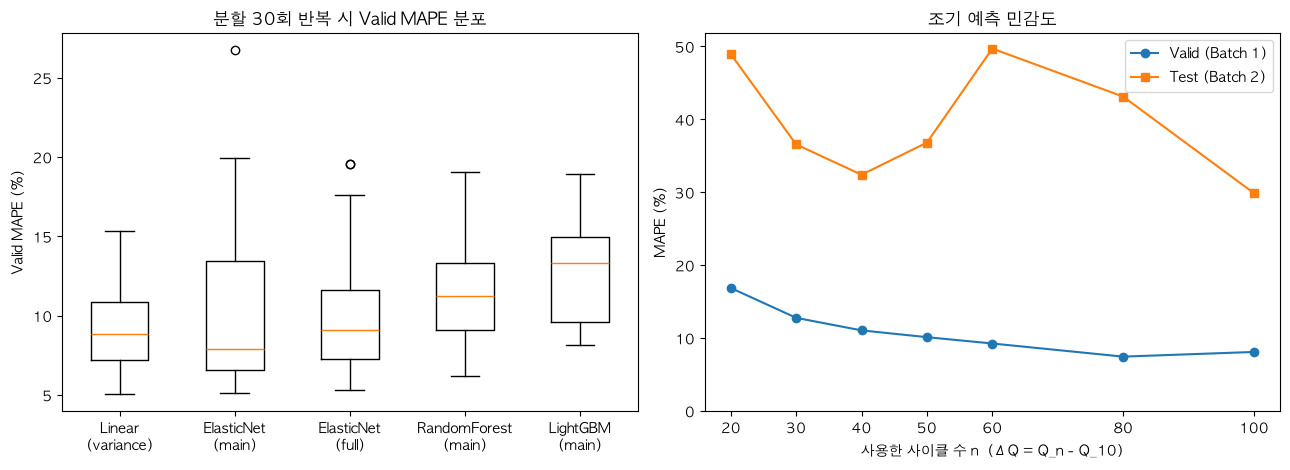


결과 저장 → /Users/parksihyun/Desktop/ess-battery-project/results/robustness.md, robustness.png


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from robustness import run_robustness
rb = run_robustness()

In [2]:
rb['stability']

,모델,Valid 1위 횟수,Valid MAPE 평균(%),Valid MAPE 표준편차,Valid MAPE 최소~최대,Test MAPE 평균(%),Test MAPE 표준편차
0,Linear (variance),9,9.19,2.44,5.1 ~ 15.3,28.88,0.92
1,ElasticNet (main),12,10.50,5.56,5.1 ~ 26.7,36.12,7.29
2,ElasticNet (full),5,9.91,3.85,5.3 ~ 19.6,39.52,6.65
3,RandomForest (main),3,11.26,3.02,6.2 ~ 19.1,36.10,4.73
4,LightGBM (main),1,12.85,3.20,8.1 ~ 18.9,38.90,6.28


In [3]:
rb['early']

,사용 사이클 n,Batch 1 상관 r,Valid MAPE(%),Test MAPE(%),Batch 2 단수명(<550) 판별 AUC
0,20,-0.375,16.86,48.93,0.793
1,30,-0.719,12.77,36.55,0.889
2,40,-0.814,11.05,32.40,0.889
3,50,-0.696,10.12,36.81,0.930
4,60,-0.826,9.25,49.70,0.800
5,80,-0.834,7.45,43.12,0.996
6,100,-0.837,8.09,29.88,1.000
